## Rescaling and asymptotic acceleration in unconstrained quadratic optimisation

### https://doi.org/10.1007/s44007-026-00212-1

This notebook reproduces all the experiments presented in the paper A. Zverovich, M. Hutchings and B. Gauthier, *Rescaling and Asymptotic Acceleration in Unconstrained Quadratic Optimisation* (2026), La Matematica.


For a matrix $\mathbf{X}\in\mathbb{R}^{N\times m}$, 
the notation $\mathbf{X} \sim U(a,b)$ indicates that the entries of $\mathbf{X}$ are independent realisations 
of a random variable with uniform distribution on the interval $[a,b]$, <br />
$a$ and $b\in\mathbb{R}$; 
a similar convention holds for vectors (case $m=1$). 
We denote by $\mathbf{I}_{N}$ the $N\times N$ identity matrix, and we set $\mathbf{1}_{N}=(1)_{i\in[N]}$.  <br />
Unless otherwise stated (see Example 5.6), we use $N=500$. 

In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import random
import seaborn as sns
# To read in sparse matrix
import scipy.io
import urllib.request
import io
import tarfile

In [2]:
# Read in solver functions
%run QP_Solvers.py

### Example 5.1 

In this example, we set $\mathbf{Q}=\mathbf{X}\mathbf{X}^{T}$, with $m=250$ and  $\mathbf{X} \sim U(2,4)$. We also set $\mathbf{c}=\mathbf{Q}\boldsymbol{\alpha}$, with $\boldsymbol{\alpha} \sim U(-2,2)$. 

The cell below illustrates the decay of the map $D$ for two different QPs (one case with asymptotic acceleration, and one without). The considered strategies are $\mathcal{H}$-$R$, BI-$R$, CG-$D$, CD-$D$ and SR-$D$. For the $\mathcal{H}$-$R$ strategies, we also compute the evolution of the acceleration term $\mathcal{A}$. 

$\diamond$ First QP (with asymptotic acceleration).

In [3]:
np.random.seed(15) # acceleration 18 - 31

## Define Q
N = 500 ; Nrow_X = N ; Ncol_X = 250
X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
Q_mat = X_mat @ X_mat.T

## Define a solution first
QP_exact_sol = np.random.uniform(low=-2, high=2, size=N) # generate a random solution 
c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))
term_up1 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down1 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo1 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo1 = HCoo1['q'] + 1

BIVEX1 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX1 = BIVEX1['q'] + 1

GSL1 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL1 = GSL1['q'] + 1

GSLR1 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR1 = GSLR1['q'] + 1

CG1 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG1 = CG1['q'] + 1

# Acceleration term for H-R
Correc1 = 1/( 1 - (HCoo1['vQx']**2)/(HCoo1['vQv'] * HCoo1['xQx']) )

$\diamond$ Second QP (without asymptotic acceleration).

In [4]:
np.random.seed(5) # acceleration 1.03 - 1.07 

## Define Q
N = 500 ; Nrow_X = N ; Ncol_X = 250
X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X)
Q_mat = X_mat @ X_mat.T

## Define a solution first
QP_exact_sol = np.random.uniform(low=-2, high=2, size=N) # generate a random solution
c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up3 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down3 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo3 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo3 = HCoo3['q'] + 1

BIVEX3 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX3 = BIVEX3['q'] + 1

GSL3 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL3 = GSL3['q'] + 1

GSLR3 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR3 = GSLR3['q'] + 1

CG3 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG3 = CG3['q'] + 1

# Acceleration term for H-R
Correc3 = 1/( 1 - (HCoo3['vQx']**2)/(HCoo3['vQv'] * HCoo3['xQx']) )

The below cell computes the distribution of the asymptotic acceleration terms for 10,000 randomly generated QPs (execution might take a few seconds).

In [5]:
# Generate data for kernel density estimation of the acceleration term
np.random.seed(15) 
reps = 10000
correc_UB = np.zeros(reps)
correc_LB = np.zeros(reps)

for i in range(reps):

    N = 500
    Nrow_X = N
    Ncol_X = 250

    X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
    Q_mat = X_mat @ X_mat.T

    ## Define a solution first
    QP_exact_sol = np.random.uniform(low=-2, high=2, size=N) # generate a random solution
    c_vec = Q_mat @ QP_exact_sol

    diag_Q = np.diag(Q_mat)
    f_vec = np.sqrt(diag_Q)

    D0 = np.sum(c_vec * QP_exact_sol)

    # Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
    term_up = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
    term_down = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

    correc_UB[i] = term_up
    correc_LB[i] = term_down

The next cell generates Figure 3 of the paper.

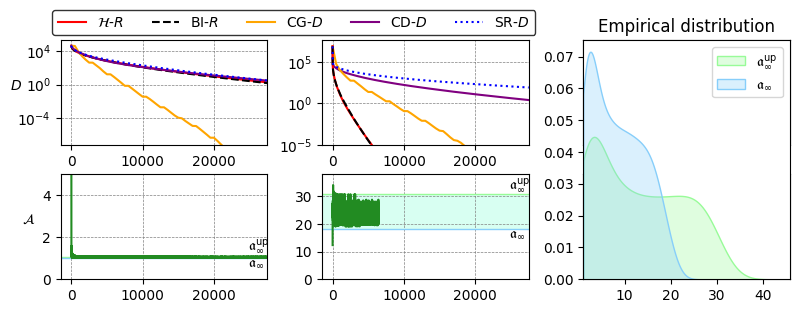

In [6]:
fig_scale = 0.9
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(fig_scale*9, fig_scale*3.5))

axes[0,0].plot(np.arange(0,n_it_HCoo3), HCoo3['D'], color='red', label='$\\mathcal{H}$-$R$')
axes[0,0].plot(np.arange(0,n_it_BIVEX3), BIVEX3['D'], color='black', label='BI-$R$', linestyle='dashed')
axes[0,0].plot(np.arange(0,n_it_CG3)*N, CG3['D_rec'], color='orange', label='CG-$D$')
axes[0,0].plot(np.arange(0,n_it_GSL3), GSL3['D'], color='purple', label='CD-$D$')
axes[0,0].plot(np.arange(0,n_it_GSLR3), GSLR3['D'], color='blue', label='SR-$D$', linestyle='dotted')

leg = fig.legend(loc='upper center', bbox_to_anchor=(0.369, 1), ncol=5)
leg.get_frame().set_edgecolor("black")

axes[0,0].set_yscale('log')
axes[0,0].set_ylabel('$D$', rotation=0, labelpad=1, loc='center')
axes[0,0].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0,0].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0,0].set_xlim(left=-1500, right=27500)
axes[0,0].set_ylim(bottom=5e-8)
axes[0,0].set_yticks(np.array([1e-4,1e0,1e4]))


axes[0,1].plot(np.arange(0,n_it_GSL1), GSL1['D'], color='purple')
axes[0,1].plot(np.arange(0,n_it_CG1)*N, CG1['D_rec'], color='orange')
axes[0,1].plot(np.arange(0,n_it_HCoo1), HCoo1['D'], color='red')
axes[0,1].plot(np.arange(0,n_it_BIVEX1), BIVEX1['D'], color='black', linestyle='dashed')
axes[0,1].plot(np.arange(0,n_it_GSLR1), GSLR1['D'], color='blue', linestyle='dotted') 

axes[0,1].set_yscale('log')
axes[0,1].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0,1].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0,1].set_xlim(left=-1500, right=27500)
axes[0,1].set_ylim(bottom=1e-5)

axes[1,2].tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
axes[0,2].tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 

# Merge axes[0,2] and axes[1,2] into one subplot
gs = fig.add_gridspec(2, 3)
big_ax = fig.add_subplot(gs[:, 2])  # This spans both rows in column 2

sns.kdeplot(data=correc_UB, color='palegreen', bw_adjust=2, alpha=0.3, label='$\\mathfrak{a}_{\\infty}^{\\mathrm{up}}$', fill=True, clip=(1, None), ax=big_ax)
sns.kdeplot(data=correc_LB, color='lightskyblue', bw_adjust=2, alpha=0.3, label='$\\mathfrak{a}_{\\infty}$', fill=True, clip=(1, None), ax=big_ax)
big_ax.set_ylabel(' ', rotation=90, labelpad=0, loc='center')
big_ax.set_xlim(left=1)
big_ax.set_xticks(np.array([10,20,30,40]))
big_ax.set_title('Empirical distribution')
big_ax.legend()

#######################
axes[1,0].hlines(term_up3, -5000, n_it_max_Lin, color='palegreen', linewidth=1.0)
axes[1,0].hlines(term_down3, -5000, n_it_max_Lin, color='lightskyblue', linewidth=1.0)
axes[1,0].plot(np.arange(1,n_it_HCoo3), Correc3, color='forestgreen')
axes[1,0].set_ylabel('$\\mathcal{A}$', rotation=0, labelpad=10, loc='center')
axes[1,0].set_xlim(left=-1500, right=27500)
axes[1,0].set_ylim(bottom=-0, top=5)
axes[1,0].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1,0].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1,0].axhspan(term_up3, term_down3, facecolor='aquamarine', alpha=0.3)
axes[1,0].text(24800, 0.59, '$\\mathfrak{a}_{\\infty}$', color='black')
axes[1,0].text(24800, 1.42, '$\\mathfrak{a}_{\\infty}^{\\mathrm{up}}$', color='black')

axes[1,1].hlines(term_up1, -5000, n_it_max_Lin, color='palegreen', linewidth=1.0)
axes[1,1].hlines(term_down1, -5000, n_it_max_Lin, color='lightskyblue', linewidth=1.0) 
axes[1,1].plot(np.arange(1,n_it_HCoo1), Correc1, color='forestgreen')
axes[1,1].set_xlim(left=-1500, right=27500)
axes[1,1].set_ylim(bottom=-0, top=38)
axes[1,1].set_yticks(np.array([0,10,20,30]))
axes[1,1].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1,1].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1,1].axhspan(term_up1, term_down1, facecolor='aquamarine', alpha=0.3) 
axes[1,1].text(24800, 15, '$\\mathfrak{a}_{\\infty}$', color='black')
axes[1,1].text(24800, 32.9, '$\\mathfrak{a}_{\\infty}^{\\mathrm{up}}$', color='black')

plt.subplots_adjust(top=0.9, hspace=0, wspace=0, left=0, right=1.2, bottom=0) # for legend space

fig.tight_layout(h_pad=0, w_pad=0) # reduce gaps between subplots

plt.show()

We now consider a variant of the above example that robustly induces asymptotic accelerations.

We set $\mathbf{Q}=\mathbf{X}\mathbf{X}^{T}$, with $m=250$ and  $\mathbf{X} \sim U(2,4)$. We also set $\mathbf{c}=\mathbf{Q}\boldsymbol{\alpha}$, with $\boldsymbol{\alpha} \sim U(0,1)$. 

The below cell computes the distribution of the asymptotic acceleration terms for 10,000 randomly generated such QPs (execution might take a few seconds).

In [7]:
# Generate data for kernel density estimation of the acceleration term
np.random.seed(15) 
reps = 10000
correc_UB = np.zeros(reps)
correc_LB = np.zeros(reps)

for i in range(reps):

    N = 500
    Nrow_X = N
    Ncol_X = 250
    
    X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
    Q_mat = X_mat @ X_mat.T

    ## Define a solution first
    QP_exact_sol = np.random.uniform(low=0, high=1, size=N) # generate a random solution
    c_vec = Q_mat @ QP_exact_sol

    diag_Q = np.diag(Q_mat)
    f_vec = np.sqrt(diag_Q)

    D0 = np.sum(c_vec * QP_exact_sol)

    # Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
    term_up = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
    term_down = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

    correc_UB[i] = term_up
    correc_LB[i] = term_down

Below we apply the considered strategies to one example QP in this setting.

In [8]:
# Optimise the final quadratic map
n_it_max_CG = 30
n_it_max_Lin = n_it_max_CG * N

HCoo1 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo1 = HCoo1['q'] + 1

BIVEX1 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX1 = BIVEX1['q'] + 1

GSL1 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL1 = GSL1['q'] + 1

GSLR1 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR1 = GSLR1['q'] + 1

CG1 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG1 = CG1['q'] + 1

The below cell generates Figure 4 of the paper.

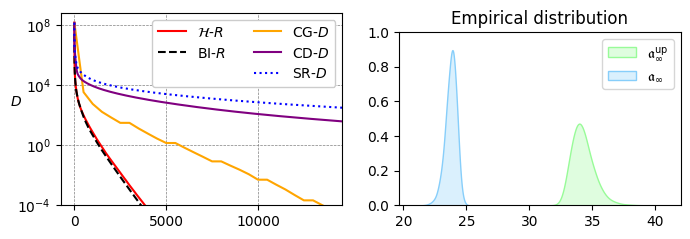

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 2.5))

axes[0].plot(np.arange(0,n_it_HCoo1), HCoo1['D'], color='red', label='$\\mathcal{H}$-$R$')
axes[0].plot(np.arange(0,n_it_BIVEX1), BIVEX1['D'], color='black', linestyle='dashed', label='BI-$R$')
axes[0].plot(np.nan, np.nan, '-', color='none', label=' ') # To create blank space in legend
axes[0].plot(np.arange(0,n_it_CG1)*N, CG1['D_rec'], color='orange', label='CG-$D$')
axes[0].plot(np.arange(0,n_it_GSL1), GSL1['D'], color='purple', label='CD-$D$')
axes[0].plot(np.arange(0,n_it_GSLR1), GSLR1['D'], color='blue', linestyle='dotted', label='SR-$D$')

axes[0].legend(loc='upper right',ncols=2,framealpha=1.0)
axes[0].set_ylabel('$D$', rotation=0, labelpad=1, loc='center')
axes[0].set_yscale('log')
axes[0].set_xlim(right=14600)
axes[0].set_ylim(bottom=10**(-4))
axes[0].set_yticks(np.array([1e-4,1e0,1e4,1e8]))
axes[0].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)

sns.kdeplot(data=correc_UB, color='palegreen', bw_adjust=2, alpha=0.3, label='$\\mathfrak{a}_{\\infty}^{\\mathrm{up}}$', fill=True, clip=(1, None), ax=axes[1]) 
sns.kdeplot(data=correc_LB, color='lightskyblue', bw_adjust=2, alpha=0.3, label='$\\mathfrak{a}_{\\infty}$', fill=True, clip=(1, None), ax=axes[1])
axes[1].set_ylabel(' ', rotation=0, labelpad=1, loc='center')
axes[1].legend()
axes[1].set_ylim(top=1)
# Shrink the second subplot
box = axes[1].get_position()
axes[1].set_position([box.x0, box.y0, box.width, box.height * 0.9])
axes[1].set_title('Empirical distribution')

plt.show()

### Example 5.2
In this example, the same matrix $\mathbf{X}$ and vector $\mathbf{c}$ as in the top-middle plot of Figure 3 are used. We explore the effect of adding different positive constants to the diagonal of the matrix $\mathbf{Q}$.

We set $\mathbf{Q}=\mathbf{X}\mathbf{X}^{T} + \gamma\mathbf{I}_{N}$, with $m=250$, $\mathbf{X} \sim U(2,4)$ and $\gamma>0$. We use $\gamma=0.5$, $5$ and $50$. We also set $\mathbf{c}=\mathbf{Q}\boldsymbol{\alpha}$, with $\boldsymbol{\alpha} \sim U(-2,2)$. <br />

The cells below illustrate the decay of the map $D$ for three different QPs with increasing values of the diagonal term $\gamma$. The considered strategies are $\mathcal{H}$-$R$, BI-$R$, CG-$D$, CD-$D$ and SR-$D$.

$\diamond$ QP with $\gamma = 0.5$.

In [10]:
np.random.seed(15) # acceleration 18 - 31

N = 500
Nrow_X = N
Ncol_X = 250

X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X)
Q_mat_0 = X_mat @ X_mat.T
eigs = np.linalg.eigvalsh(Q_mat_0)
print("Smallest non-zero singular value of XX^T:", eigs[-Ncol_X])

## Define a solution first
QP_exact_sol = np.random.uniform(low=-2, high=2, size=N) # generate a random solution

Q_mat = Q_mat_0 + 0.5 * np.eye(N)

c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up1 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down1 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))


## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo1 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo1 = HCoo1['q'] + 1

BIVEX1 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX1 = BIVEX1['q'] + 1

GSL1 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL1 = GSL1['q'] + 1

GSLR1 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR1 = GSLR1['q'] + 1

CG1 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG1 = CG1['q'] + 1

Smallest non-zero singular value of XX^T: 14.197264627406364


$\diamond$ QP with $\gamma = 5$.

In [11]:
Q_mat = Q_mat_0 + 5 * np.eye(N) 
c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up2 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down2 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))


## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo2 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo2 = HCoo2['q'] + 1

BIVEX2 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX2 = BIVEX2['q'] + 1

GSL2 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL2 = GSL2['q'] + 1

GSLR2 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR2 = GSLR2['q'] + 1

CG2 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG2 = CG2['q'] + 1

$\diamond$ QP with $\gamma = 50$.

In [12]:
Q_mat = Q_mat_0 + 50 * np.eye(N) 
c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up3 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down3 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))


## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo3 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo3 = HCoo3['q'] + 1

BIVEX3 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX3 = BIVEX3['q'] + 1

GSL3 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL3 = GSL3['q'] + 1

GSLR3 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0) 
n_it_GSLR3 = GSLR3['q'] + 1

CG3 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG3 = CG3['q'] + 1

The below cell generates Figure 5 of the paper.

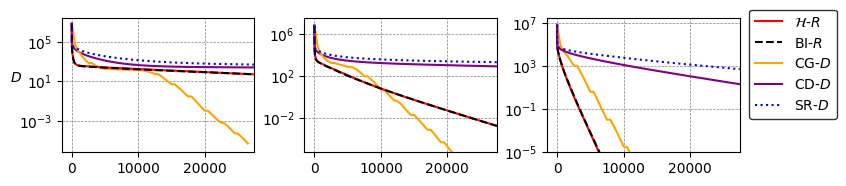

In [13]:
fig_scale = 0.95
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(8*fig_scale, 2*fig_scale))

axes[0].plot(np.arange(0,n_it_GSL1), GSL1['D'], color='purple')
axes[0].plot(np.arange(0,n_it_CG1)*N, CG1['D_rec'], color='orange')
axes[0].plot(np.arange(0,n_it_HCoo1), HCoo1['D'], color='red')
axes[0].plot(np.arange(0,n_it_BIVEX1), BIVEX1['D'], color='black', linestyle='dashed')
axes[0].plot(np.arange(0,n_it_GSLR1), GSLR1['D'], color='blue', linestyle='dotted') 

axes[0].set_yscale('log')
axes[0].set_ylabel('$D$', rotation=0, labelpad=2, loc='center')
axes[0].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0].set_xlim(left=-1500, right=27500)
axes[0].set_ylim(bottom=6e-7)

axes[1].plot(np.arange(0,n_it_GSL2), GSL2['D'], color='purple')
axes[1].plot(np.arange(0,n_it_CG2)*N, CG2['D_rec'], color='orange')
axes[1].plot(np.arange(0,n_it_HCoo2), HCoo2['D'], color='red')
axes[1].plot(np.arange(0,n_it_BIVEX2), BIVEX2['D'], color='black', linestyle='dashed')
axes[1].plot(np.arange(0,n_it_GSLR2), GSLR2['D'], color='blue', linestyle='dotted')

axes[1].set_yscale('log')
axes[1].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1].set_xlim(left=-1500, right=27500)
axes[1].set_ylim(bottom=5e-6)

axes[2].plot(np.arange(0,n_it_HCoo3), HCoo3['D'], color='red', label='$\\mathcal{H}$-$R$')
axes[2].plot(np.arange(0,n_it_BIVEX3), BIVEX3['D'], color='black', label='$\\mathrm{BI}$-$R$', linestyle='dashed')
axes[2].plot(np.arange(0,n_it_CG3)*N, CG3['D_rec'], color='orange', label='$\\mathrm{CG}$-$D$')
axes[2].plot(np.arange(0,n_it_GSL3), GSL3['D'], color='purple', label='$\\mathrm{CD}$-$D$')
axes[2].plot(np.arange(0,n_it_GSLR3), GSLR3['D'], color='blue', label='$\\mathrm{SR}$-$D$', linestyle='dotted')


leg = fig.legend(loc='lower center', bbox_to_anchor=(1.05, 0.345), ncol=1)
leg.get_frame().set_edgecolor("black")
axes[2].set_yscale('log')
axes[2].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[2].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[2].set_xlim(left=-1500, right=27500)
axes[2].set_ylim(bottom=1e-5)


fig.tight_layout(h_pad=0, w_pad=0.5) # reduce gaps between subplots

plt.show()

### Example 5.3
We set $\mathbf{Q}=\mathbf{X}\mathbf{X}^{T}$, with $m=650$ and  $\mathbf{X} \sim U(2,4)$. For the same realisation of $\mathbf{Q}$, we define three different solution vectors 
$\boldsymbol{\alpha}$, with sparsity levels $50\%$, $70\%$ and $90\%$, respectively; the non-zero entries of $\boldsymbol{\alpha}$ are randomly generated from $U(-2,2)$, and we set $\mathbf{c}=\mathbf{Q}\boldsymbol{\alpha}$.

The cells below illustrate the decay of the map $D$ for the three different QPs with varying sparsities of $\boldsymbol{\alpha}$. The considered strategies are $\mathcal{H}$-$R$, BI-$R$, CG-$D$, CD-$D$ and SR-$D$.

$\diamond$ Sparsity level of $\boldsymbol{\alpha}$: 90%.

In [14]:
# 90% sparsity
np.random.seed(6)
random.seed(5)
sparsity=0.9

N = 500 ; Nrow_X = N ; Ncol_X = 650
X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
Q_mat = X_mat @ X_mat.T

## Define a solution first
QP_exact_sol = np.random.uniform(low=-2, high=2, size=N) # generate a random solution 
num_zero = round(N*sparsity)
samp = random.sample(range(N), num_zero)
QP_exact_sol[samp] = 0

c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up1 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down1 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo1 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo1 = HCoo1['q'] + 1

BIVEX1 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX1 = BIVEX1['q'] + 1

GSL1 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL1 = GSL1['q'] + 1

GSLR1 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR1 = GSLR1['q'] + 1

CG1 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG1 = CG1['q'] + 1

$\diamond$ Sparsity level of $\boldsymbol{\alpha}$: 70%.

In [15]:
# 70% sparsity
np.random.seed(6)
random.seed(5)
sparsity=0.7

## Define Q
N = 500 ; Nrow_X = N ; Ncol_X = 650
X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
Q_mat = X_mat @ X_mat.T

## Define a solution first
QP_exact_sol = np.random.uniform(low=-2, high=2, size=N) # generate a random solution 
num_zero = round(N*sparsity)
samp = random.sample(range(N), num_zero)
QP_exact_sol[samp] = 0

c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up2 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down2 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo2 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo2 = HCoo2['q'] + 1

BIVEX2 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX2 = BIVEX2['q'] + 1

GSL2 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL2 = GSL2['q'] + 1

GSLR2 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR2 = GSLR2['q'] + 1

CG2 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG2 = CG2['q'] + 1 

$\diamond$ Sparsity level of $\boldsymbol{\alpha}$: 50%.

In [16]:
# 50% sparsity
np.random.seed(6) 
random.seed(5)
sparsity=0.5

## Define Q
N = 500 ; Nrow_X = N ; Ncol_X = 650
X_mat = np.random.uniform(low=2, high=4, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
Q_mat = X_mat @ X_mat.T

## Define a solution first
QP_exact_sol = np.random.uniform(low=-2, high=2, size=N) # generate a random solution 
num_zero = round(N*sparsity)
samp = random.sample(range(N), num_zero)
QP_exact_sol[samp] = 0

c_vec = Q_mat @ QP_exact_sol

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up3 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down3 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

## Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo3 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo3 = HCoo3['q'] + 1

BIVEX3 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX3 = BIVEX3['q'] + 1

GSL3 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL3 = GSL3['q'] + 1

GSLR3 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR3 = GSLR3['q'] + 1

CG3 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG3 = CG3['q'] + 1

The below cell generates Figure 6 of the paper.

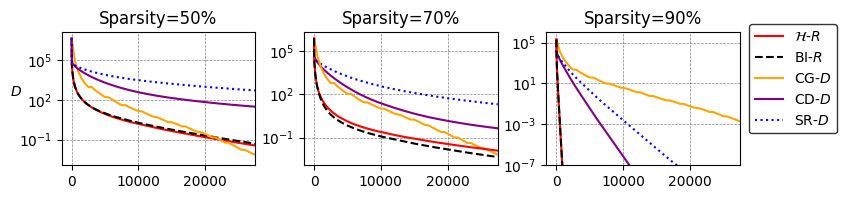

In [17]:
fig_scale = 0.95
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(fig_scale*8, fig_scale*2.2)) 

axes[0].plot(np.arange(0,n_it_HCoo3), HCoo3['D'], color='red', label='$\\mathcal{H}$-$R$')
axes[0].plot(np.arange(0,n_it_BIVEX3), BIVEX3['D'], color='black', label='$\\mathrm{BI}$-$R$', linestyle='dashed')
axes[0].plot(np.arange(0,n_it_CG3)*N, CG3['D_rec'], color='orange', label='$\\mathrm{CG}$-$D$')
axes[0].plot(np.arange(0,n_it_GSL3), GSL3['D'], color='purple', label='$\\mathrm{CD}$-$D$')
axes[0].plot(np.arange(0,n_it_GSLR3), GSLR3['D'], color='blue', label='$\\mathrm{SR}$-$D$', linestyle='dotted')

axes[0].set_yscale('log')
axes[0].set_ylabel("$D$", rotation=0, labelpad=2)
axes[0].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0].set_xlim(right=27500)
axes[0].set_yticks(np.array([1e5,1e2,1e-1]))
axes[0].set_title("Sparsity=50%")

axes[1].plot(np.arange(0,n_it_GSL2), GSL2['D'], color='purple')
axes[1].plot(np.arange(0,n_it_GSLR2), GSLR2['D'], color='blue', linestyle='dotted')
axes[1].plot(np.arange(0,n_it_CG2)*N, CG2['D_rec'], color='orange')
axes[1].plot(np.arange(0,n_it_HCoo2), HCoo2['D'], color='red')
axes[1].plot(np.arange(0,n_it_BIVEX2), BIVEX2['D'], color='black', linestyle='dashed')

axes[1].set_yscale('log')
axes[1].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1].set_xlim(right=27500)
axes[1].set_yticks(np.array([1e5,1e2,1e-1]))
axes[1].set_title("Sparsity=70%")

axes[2].plot(np.arange(0,n_it_GSL1), GSL1['D'], color='purple')
axes[2].plot(np.arange(0,n_it_GSLR1), GSLR1['D'], color='blue', linestyle='dotted')
axes[2].plot(np.arange(0,n_it_CG1)*N, CG1['D_rec'], color='orange')
axes[2].plot(np.arange(0,n_it_HCoo1), HCoo1['D'], color='red')
axes[2].plot(np.arange(0,n_it_BIVEX1), BIVEX1['D'], color='black', linestyle='dashed')

axes[2].set_yscale('log')
axes[2].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[2].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[2].set_xlim(right=27500)
axes[2].set_ylim(bottom=1e-7)
axes[2].set_title("Sparsity=90%")

leg = fig.legend(loc='lower center', bbox_to_anchor=(1.05, 0.305), ncol=1) 
leg.get_frame().set_edgecolor("black")


fig.tight_layout(h_pad=0, w_pad=0.4) # reduce gaps between subplots

plt.show()

### Example 5.4
In this example, we illustrate the decay of $D$ for the considered strategies where the observed acceleration is induced by the simple-rescaling mechanism alone. The considered strategies are $\mathcal{H}$-$R$, BI-$R$, CG-$D$, CD-$D$ and SR-$D$.

We set $\mathbf{Q}=\mathbf{X}\mathbf{X}^{T}$, with $m=650$ and  $\mathbf{X} \sim U(-2,3)$. We also set $\mathbf{c}\sim U(3,5)$. 

In [18]:
np.random.seed(5) 

N = 500
Nrow_X = N
Ncol_X = 650

X_mat = np.random.uniform(low=-2, high=3, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
Q_mat = X_mat @ X_mat.T

## Define RHS term first
Q_mat_ginv = la.pinv(Q_mat)
c_vec  = np.random.uniform(low=3, high=5, size=N)
QP_exact_sol = Q_mat_ginv @ c_vec

diag_Q = np.diag(Q_mat)
f_vec = np.sqrt(diag_Q)

D0 = np.sum(c_vec * QP_exact_sol)

diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))

#Optim
n_it_max_CG = 60
n_it_max_Lin = n_it_max_CG * N

HCoo = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo = HCoo['q'] + 1

BIVEX = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX = BIVEX['q'] + 1

GSL = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL = GSL['q'] + 1

GSLR = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR = GSLR['q'] + 1

CG = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG = CG['q'] + 1

The below cell generates Figure 7 of the paper.

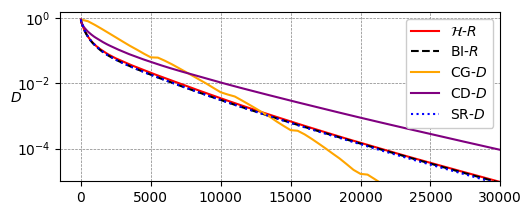

In [19]:
width = 6 ; height = 2.5
fig_scale = 0.9
plt.figure(figsize=(fig_scale*width, fig_scale*height))

plt.plot(np.arange(0,n_it_HCoo), HCoo['D'], color='red', label='$\\mathcal{H}$-$R$')
plt.plot(np.arange(0,n_it_BIVEX), BIVEX['D'], color='black', linestyle='dashed', label='$\\mathrm{BI}$-$R$')
plt.plot(np.arange(0,n_it_CG)*N, CG['D_rec'], color='orange', label='$\\mathrm{CG}$-$D$')
plt.plot(np.arange(0,n_it_GSL), GSL['D'], color='purple', label='$\\mathrm{CD}$-$D$')
plt.plot(np.arange(0,n_it_GSLR), GSLR['D'], color='blue', linestyle='dotted', label='$\\mathrm{SR}$-$D$')

plt.ylabel("$D$", rotation=0, labelpad=5)
plt.gca().yaxis.set_label_coords(-0.1, 0.45) # move ylabel downwards

plt.legend(framealpha=1.0)
plt.ylim(bottom=10**(-5), top=1.5)
plt.xlim(right=30000)
plt.grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
plt.grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)

plt.yscale('log')
plt.yticks(np.array([1e0,1e-2,1e-4]))
plt.gca().yaxis.set_minor_locator(plt.NullLocator()) # remove minor axis ticks


plt.tight_layout(h_pad=0, w_pad=0) # reduce gaps between subplots

plt.show()

### Example 5.5
Consider a set of $N=500$ random points uniformly distributed in $[0,1]^{5}$; denote by $\mathbf{K}$ the kernel matrix defined by this set of points 
and a kernel of the form $(x,x')\mapsto\exp(-\zeta\|x-x'\|^{2})$, with $\zeta=0.13$ (Gaussian kernel, with $\|.\|$ the Euclidean norm); we also define $\mathbf{v}\sim U(0,1)$. We then set 
$$\mathbf{Q} = \mathbf{K} + \gamma\mathbf{I}_{N} + \beta\mathbf{1}_N\mathbf{1}_N^T
\quad\text{and}\quad
\mathbf{c} = \mathbf{v} + \delta\mathbf{1}_N,$$
with $\gamma=1$ 
and either $\beta=\delta=0$ (Case 1), 
$\beta=0$ and $\delta=100$ (Case 2), or 
$\beta=1$ and $\delta=100$ (Case 3).

The considered strategies are $\mathcal{H}$-$R$, BI-$R$, CG-$D$, CD-$D$ and SR-$D$.

Below we define the kernel function.

In [20]:
# Compute the kernel matrix between x and y with kernel parameter rho
def GaussKernel(x, y, rho):
    sq_dist = np.sum(np.square(x-y))
    return np.exp(-rho*sq_dist)

$\diamond$ Case 1.

In [21]:
np.random.seed(9)

N = 500 
Nrow_X = N
Ncol_X = 5 

#Additive constants
c_add = 100
Q_add = 1

#Define Q_mat
X_mat = np.random.uniform(low=0, high=1, size=Nrow_X * Ncol_X).reshape(Nrow_X, Ncol_X) 
Q_mat = np.zeros((Nrow_X, Nrow_X))

for i in range(Nrow_X):
    for j in range(i+1):
        Q_mat[i,j] = GaussKernel(X_mat[i,:],X_mat[j,:],rho=0.13)
        Q_mat[j,i] = Q_mat[i,j]

Q_mat += 1*np.eye(N)
Q_base = Q_mat

#Define RHS first
c_vec = np.random.uniform(low=0, high=1, size=N) 
c_base = c_vec

QP_exact_sol = np.linalg.solve(Q_mat, c_vec) 


D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))

# Compute asymptotic acceleration terms (a_infinity^up and a_infinity)
term_up1 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down1 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))


## Optim
n_it_max_CG = 30
n_it_max_Lin = n_it_max_CG * N

HCoo1 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo1 = HCoo1['q'] + 1

BIVEX1 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX1 = BIVEX1['q'] + 1

GSL1 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL1 = GSL1['q'] + 1

GSLR1 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR1 = GSLR1['q'] + 1

CG1 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG1 = CG1['q'] + 1

$\diamond$ Case 2.

In [22]:
np.random.seed(9)

c_vec = c_base + c_add
Q_mat = Q_base

#Define RHS first
QP_exact_sol = np.linalg.solve(Q_mat, c_vec)

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))
term_up2 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down2 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))


## Optim
n_it_max_CG = 30
n_it_max_Lin = n_it_max_CG * N

HCoo2 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo2 = HCoo2['q'] + 1

BIVEX2 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX2 = BIVEX2['q'] + 1

GSL2 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL2 = GSL2['q'] + 1

GSLR2 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR2 = GSLR2['q'] + 1

CG2 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG2 = CG2['q'] + 1

$\diamond$ Case 3.

In [23]:
np.random.seed(9)

c_vec = c_base + c_add
Q_mat = Q_base + Q_add

#Define RHS first
QP_exact_sol = np.linalg.solve(Q_mat, c_vec) 

D0 = np.sum(c_vec * QP_exact_sol)
diag_Q = np.abs(np.diag(Q_mat))
term_up4 = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down4 = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))


## Optim
n_it_max_CG = 30
n_it_max_Lin = n_it_max_CG * N

HCoo4 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo4 = HCoo4['q'] + 1

BIVEX4 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX4 = BIVEX4['q'] + 1

GSL4 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL4 = GSL4['q'] + 1

GSLR4 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR4 = GSLR4['q'] + 1

CG4 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG4 = CG4['q'] + 1

The below cell generates Figure 8 of the paper.

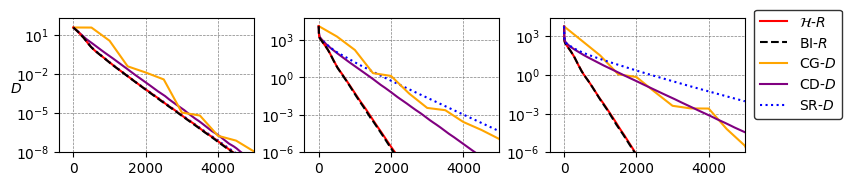

In [24]:
fig_scale = 0.95
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(fig_scale*8, fig_scale*2)) 

axes[0].plot(np.arange(0,n_it_GSL1), GSL1['D'], color='purple')
axes[0].plot(np.arange(0,n_it_GSLR1), GSLR1['D'], color='blue', linestyle='dotted')
axes[0].plot(np.arange(0,n_it_CG1)*N, CG1['D_rec'], color='orange')
axes[0].plot(np.arange(0,n_it_HCoo1), HCoo1['D'], color='red')
axes[0].plot(np.arange(0,n_it_BIVEX1), BIVEX1['D'], color='black', linestyle='dashed')

axes[0].set_yscale('log')
axes[0].set_ylabel("$D$", rotation=0, labelpad=4)
axes[0].yaxis.set_label_coords(-0.22, 0.42)
axes[0].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[0].set_xlim(left=-400, right=5000)
axes[0].set_ylim(bottom=1e-8)

axes[1].plot(np.arange(0,n_it_GSL2), GSL2['D'], color='purple')
axes[1].plot(np.arange(0,n_it_GSLR2), GSLR2['D'], color='blue', linestyle='dotted')
axes[1].plot(np.arange(0,n_it_CG2)*N, CG2['D_rec'], color='orange')
axes[1].plot(np.arange(0,n_it_HCoo2), HCoo2['D'], color='red')
axes[1].plot(np.arange(0,n_it_BIVEX2), BIVEX2['D'], color='black', linestyle='dashed')

axes[1].set_yscale('log')
axes[1].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[1].set_xlim(left=-400, right=5000)
axes[1].set_ylim(bottom=1e-6)

axes[2].plot(np.arange(0,n_it_HCoo4), HCoo4['D'], color='red', label='$\\mathcal{H}$-$R$')
axes[2].plot(np.arange(0,n_it_BIVEX4), BIVEX4['D'], color='black', linestyle='dashed', label='$\\mathrm{BI}$-$R$')
axes[2].plot(np.arange(0,n_it_CG4)*N, CG4['D_rec'], color='orange', label='$\\mathrm{CG}$-$D$')
axes[2].plot(np.arange(0,n_it_GSL4), GSL4['D'], color='purple', label='$\\mathrm{CD}$-$D$')
axes[2].plot(np.arange(0,n_it_GSLR4), GSLR4['D'], color='blue', linestyle='dotted', label='$\\mathrm{SR}$-$D$')

axes[2].set_yscale('log')
axes[2].grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[2].grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
axes[2].set_xlim(left=-400, right=5000)
axes[2].set_ylim(bottom=1e-6)

leg = fig.legend(loc='lower center', bbox_to_anchor=(1.05, 0.345), ncol=1)
leg.get_frame().set_edgecolor("black")

fig.tight_layout(h_pad=0, w_pad=0.5) # reduce gaps between subplots

plt.show()

### Example 5.6
In this example, we consider the sparse matrix $\mathbf{M}$ corresponding to the *1138\_bus* instance of the SuiteSparse Matrix Collection (https://sparse.tamu.edu/; $N=1{,}138$). We illustrate an acceleration induced by the simple rescaling of the iterates. The considered strategies are $\mathcal{H}$-$R$, BI-$R$, CG-$D$, CD-$D$ and SR-$D$.

We set $\mathbf{Q}=\mathbf{M}+\gamma\mathbf{I}_{N}$ with $\gamma = 1$, and $\mathbf{c}\sim U(-1,1)$.  

Below we download the *1138\_bus* matrix and load it into the SciPy sparse format.

In [25]:
# Define the URL for the 1138_bus matrix. Note: SuiteSparse matrices are often stored in .tar.gz files
url = "https://suitesparse-collection-website.herokuapp.com/MM/HB/1138_bus.tar.gz"
 
# 1. Download the compressed file
with urllib.request.urlopen(url) as response:
    with tarfile.open(fileobj=io.BytesIO(response.read()), mode="r:gz") as tar:
        # The .mtx file is usually inside the tar archive
        for member in tar.getmembers():
            if member.name.endswith(".mtx"):
                f = tar.extractfile(member)
                # 2. Load the matrix into a SciPy sparse format
                M = scipy.io.mmread(f)
                break 

We now apply the minimisation strategies to the QP generated with this matrix (execution might take a few seconds).

In [26]:
np.random.seed(4)

# Read in the sparse matrix as numpy array
Q_mat = np.array(M.toarray())
N = np.shape(Q_mat)[0]
Q_mat += 1*np.eye(N)

# Generate c_vec first
c_vec = np.random.uniform(low=-1, high=1, size=N)
QP_exact_sol = np.linalg.solve(Q_mat, c_vec)

diag_Q = np.diag(Q_mat)
f_vec = np.sqrt(diag_Q)

D0 = np.sum(c_vec * QP_exact_sol)

diag_Q = np.abs(np.diag(Q_mat))

term_up = np.max(1/(1 - (c_vec**2)/(diag_Q * D0)))
term_down = np.min(1/(1 - (c_vec**2)/(diag_Q * D0)))


n_it_max_CG = 300
n_it_max_Lin = n_it_max_CG * N

HCoo2 = R_HCoo_Solver_All(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_HCoo2 = HCoo2['q'] + 1

BIVEX2 = R_BICoo_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_BIVEX2 = BIVEX2['q'] + 1

GSL2 = D_GSL_Solver(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSL2 = GSL2['q'] + 1

GSLR2 = D_GSL_Solver_Rescale(n_it_max_Lin, Q_mat, c_vec, D0)
n_it_GSLR2 = GSLR2['q'] + 1

CG2 = CG_Solver(n_it_max_CG+1, Q_mat, c_vec, D0)
n_it_CG2 = CG2['q'] + 1

The below cell generates Figure 9 of the paper.

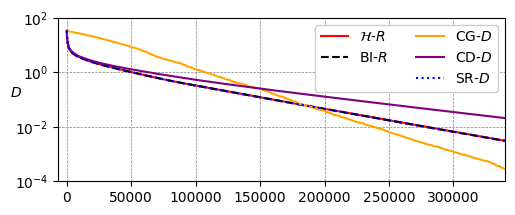

In [27]:
width = 5.25 ; height = 2.25 
plt.figure(figsize=(width, height))

plt.plot(np.arange(0,n_it_HCoo2), HCoo2['D'], color='red', label='$\\mathcal{H}$-$R$')
plt.plot(np.arange(0,n_it_BIVEX2), BIVEX2['D'], color='black', linestyle='dashed', label='$\\mathrm{BI}$-$R$')
plt.plot(np.nan, np.nan, '-', color='none', label=' ')
plt.plot(np.arange(0,n_it_CG2)*N, CG2['D_rec'], color='orange', label='$\\mathrm{CG}$-$D$')
plt.plot(np.arange(0,n_it_GSL2), GSL2['D'], color='purple', label='$\\mathrm{CD}$-$D$') 
plt.plot(np.arange(0,n_it_GSLR2), GSLR2['D'], color='blue', linestyle='dotted', label='$\\mathrm{SR}$-$D$')

plt.ylabel("$D$", rotation=0, labelpad=-1)
plt.xlim(left=-7000,right=340000)
plt.grid(which='major', axis='x', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
plt.grid(which='major', axis='y', zorder=-1.0, 
             color='gray', linestyle='dashed',linewidth=0.5)
plt.legend(framealpha=1.0, loc='upper right',ncols=2)
plt.yscale('log')
plt.yticks(np.array([1e-4,1e-2,1,100]))
plt.gca().yaxis.set_minor_locator(plt.NullLocator()) # Remove minor ticks from y axis

plt.tight_layout(h_pad=0, w_pad=0) # reduce gaps between subplots

plt.show()